<a href="https://colab.research.google.com/github/Amitabh-Phule/Reinforcement-Learning/blob/main/RL_Exp_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**
Temporal Difference (TD) Learning – TD(0) Prediction

## **Aim**
To implement TD(0) prediction and compare Temporal Difference estimation with Monte Carlo estimation.

## **Theory**
Temporal Difference (TD) Learning is a model-free reinforcement learning method used to estimate the value of states.

TD learning updates the value function after every step, without waiting for the complete episode to finish.

In TD(0), the value function is updated using:

V(St) ← V(St) + α[Rt+1 + γV(St+1) − V(St)]

where:

V(St) = Current value of state St
α = Learning rate
Rt+1 = Reward received after taking an action
γ = Discount factor
V(St+1) = Value of the next state

The term:

Rt+1 + γV(St+1)

is called the TD target.

The difference:

Rt+1 + γV(St+1) − V(St)

is called the TD error.

Monte Carlo methods wait until an entire episode is completed before updating the value function, whereas TD(0) can update the value after every transition.

In this experiment, TD(0) and Monte Carlo prediction are implemented on the Random Walk environment and their estimated state values are compared.

## **Algorithm**

1. Create the Random Walk environment.

2. Define the states and terminal states.

3. Initialize the value function for all states.

4. Set the learning rate α and discount factor γ.

5. For TD(0):
   a. Start a new episode.
   b. Select the next state.
   c. Observe the reward.
   d. Update the current state's value using the TD(0) equation.
   e. Continue until the episode terminates.

6. For Monte Carlo:
   a. Generate a complete episode.
   b. Calculate the return from each visited state.
   c. Update the value function using the calculated return.

7. Repeat the training process for multiple episodes.

8. Compare the TD(0) and Monte Carlo value estimates.

9. Plot both value functions.

## **Import Required Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

Define Random Walk Environment

In [2]:
## **Define Random Walk Environment**

# States: 0 and 6 are terminal states
# States 1 to 5 are non-terminal states

states = list(range(7))
non_terminal_states = list(range(1, 6))

left_terminal = 0
right_terminal = 6

print("States:", states)
print("Non-terminal states:", non_terminal_states)
print("Terminal states:", [left_terminal, right_terminal])

States: [0, 1, 2, 3, 4, 5, 6]
Non-terminal states: [1, 2, 3, 4, 5]
Terminal states: [0, 6]


## **Define State Transition**

In [3]:
## **Define State Transition**

def step(state):

    # Randomly move left or right
    direction = np.random.choice([-1, 1])

    next_state = state + direction

    # Reward is given only when reaching the right terminal state
    if next_state == right_terminal:
        reward = 1
    else:
        reward = 0

    return next_state, reward

## **Implement TD(0) Prediction**

In [4]:
## **Implement TD(0) Prediction**

alpha = 0.1
gamma = 1.0
n_episodes = 500

# Initialize value function
V_td = {state: 0.0 for state in states}

# Terminal state values
V_td[left_terminal] = 0.0
V_td[right_terminal] = 1.0

for episode in range(n_episodes):

    # Start from the middle state
    state = 3

    while state not in [left_terminal, right_terminal]:

        next_state, reward = step(state)

        # TD(0) update
        td_target = reward + gamma * V_td[next_state]

        td_error = td_target - V_td[state]

        V_td[state] += alpha * td_error

        state = next_state

print("TD(0) prediction completed.")

TD(0) prediction completed.


## **Implement Monte Carlo Prediction**

In [5]:
## **Implement Monte Carlo Prediction**

V_mc = {state: 0.0 for state in states}

V_mc[left_terminal] = 0.0
V_mc[right_terminal] = 1.0

returns_sum = {
    state: 0.0
    for state in states
}

returns_count = {
    state: 0
    for state in states
}

for episode in range(n_episodes):

    state = 3

    episode_data = []

    # Generate complete episode
    while state not in [left_terminal, right_terminal]:

        next_state, reward = step(state)

        episode_data.append(
            (state, reward)
        )

        state = next_state

    # Calculate returns
    G = 0

    visited = set()

    for state, reward in reversed(episode_data):

        G = reward + gamma * G

        # First-visit Monte Carlo
        if state not in visited:

            visited.add(state)

            returns_sum[state] += G
            returns_count[state] += 1

            V_mc[state] = (
                returns_sum[state]
                / returns_count[state]
            )

print("Monte Carlo prediction completed.")

Monte Carlo prediction completed.


## **Display TD(0) Values**

In [6]:
## **Display TD(0) Value Function**

print("========== TD(0) VALUE FUNCTION ==========")

for state in non_terminal_states:
    print(
        f"State {state}: {V_td[state]:.4f}"
    )

========== TD(0) VALUE FUNCTION ==========
State 1: 0.4137
State 2: 0.7107
State 3: 0.9958
State 4: 1.3413
State 5: 1.7446


## **Display Monte Carlo Values**

In [7]:
## **Display Monte Carlo Value Function**

print("========== MONTE CARLO VALUE FUNCTION ==========")

for state in non_terminal_states:
    print(
        f"State {state}: {V_mc[state]:.4f}"
    )

========== MONTE CARLO VALUE FUNCTION ==========
State 1: 0.1405
State 2: 0.3169
State 3: 0.4740
State 4: 0.6156
State 5: 0.7900


## **Compare TD(0) and Monte Carlo**

In [8]:
## **Compare TD(0) and Monte Carlo**

print("========== COMPARISON ==========")

print(
    f"{'State':<10}"
    f"{'TD(0)':<15}"
    f"{'Monte Carlo':<15}"
)

for state in non_terminal_states:

    print(
        f"{state:<10}"
        f"{V_td[state]:<15.4f}"
        f"{V_mc[state]:<15.4f}"
    )

========== COMPARISON ==========
State     TD(0)          Monte Carlo    
1         0.4137         0.1405         
2         0.7107         0.3169         
3         0.9958         0.4740         
4         1.3413         0.6156         
5         1.7446         0.7900         


## **Plot Value Functions**

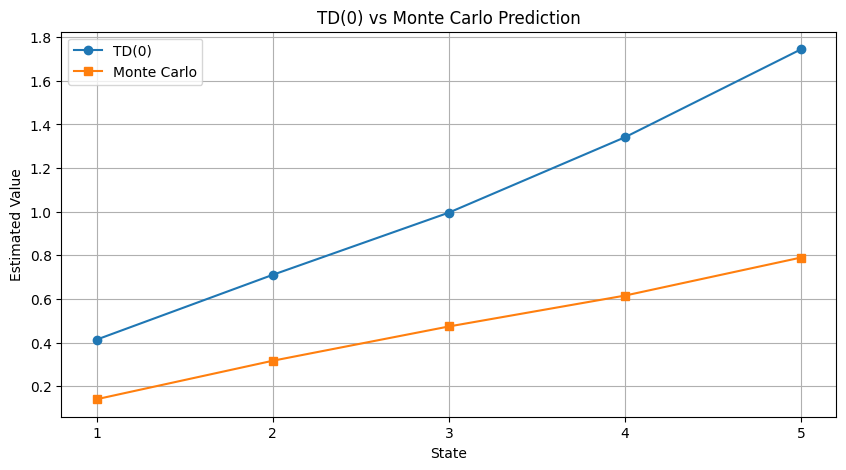

In [9]:
## **Plot TD(0) and Monte Carlo Value Functions**

td_values = [
    V_td[state]
    for state in non_terminal_states
]

mc_values = [
    V_mc[state]
    for state in non_terminal_states
]

plt.figure(figsize=(10, 5))

plt.plot(
    non_terminal_states,
    td_values,
    marker="o",
    label="TD(0)"
)

plt.plot(
    non_terminal_states,
    mc_values,
    marker="s",
    label="Monte Carlo"
)

plt.xlabel("State")
plt.ylabel("Estimated Value")

plt.title("TD(0) vs Monte Carlo Prediction")

plt.xticks(non_terminal_states)

plt.legend()
plt.grid(True)

plt.show()

## **Display True Values**

In [10]:
## **Display True State Values**

# For the Random Walk problem, the true value
# increases linearly from the left terminal to
# the right terminal.

true_values = {
    state: state / 6
    for state in non_terminal_states
}

print("========== TRUE VALUES ==========")

for state in non_terminal_states:
    print(
        f"State {state}: {true_values[state]:.4f}"
    )

========== TRUE VALUES ==========
State 1: 0.1667
State 2: 0.3333
State 3: 0.5000
State 4: 0.6667
State 5: 0.8333


## **Compare with True Values**

In [11]:
## **Compare TD(0), Monte Carlo and True Values**

print("========== FINAL COMPARISON ==========")

print(
    f"{'State':<10}"
    f"{'TD(0)':<12}"
    f"{'Monte Carlo':<15}"
    f"{'True Value':<12}"
)

for state in non_terminal_states:

    print(
        f"{state:<10}"
        f"{V_td[state]:<12.4f}"
        f"{V_mc[state]:<15.4f}"
        f"{true_values[state]:<12.4f}"
    )

========== FINAL COMPARISON ==========
State     TD(0)       Monte Carlo    True Value  
1         0.4137      0.1405         0.1667      
2         0.7107      0.3169         0.3333      
3         0.9958      0.4740         0.5000      
4         1.3413      0.6156         0.6667      
5         1.7446      0.7900         0.8333      


## **Observation**

1. The Random Walk environment was successfully implemented.

2. TD(0) updated the value function after every state transition.

3. Monte Carlo updated the value function after completing an entire episode.

4. TD(0) uses the estimated value of the next state to update the current state.

5. Monte Carlo uses the actual return obtained from the complete episode.

6. Both methods learned value estimates for the non-terminal states.

7. The estimated values generally increased as the states became closer
   to the right terminal state.

8. TD(0) and Monte Carlo produced similar value estimates after sufficient training.

## **Conclusion**

TD(0) prediction was successfully implemented and compared with Monte Carlo prediction using the Random Walk environment.

The experiment demonstrated that TD(0) can learn from each transition without waiting for an episode to finish, while Monte Carlo methods wait until the complete episode is available.

Both methods successfully estimated the value function of the environment.